# Customer Churn Prediction — Telco Dataset

**Tujuan:** Memprediksi pelanggan yang berpotensi berhenti berlangganan (churn), memahami faktor pendorongnya, dan menerjemahkan hasil model menjadi rekomendasi bisnis konkret.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Struktur analisis:**
1. Exploratory Data Analysis (EDA)
2. Data Cleaning & Feature Engineering
3. Handling Imbalanced Data (SMOTE)
4. Modeling — Logistic Regression, Random Forest, XGBoost
5. Evaluasi Model (Precision-Recall, ROC-AUC)
6. Interpretasi Model dengan SHAP
7. Business Insight & Rekomendasi

> Catatan: notebook ini secara default membaca `data/sample_telco_churn.csv` (data sintetis untuk demo).
> Ganti path di cell berikutnya ke file asli Kaggle (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) begitu sudah diunduh — struktur kolomnya identik sehingga seluruh pipeline tetap jalan tanpa perubahan.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [49]:
# DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
DATA_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Exploratory Data Analysis (EDA)

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
# Kolom TotalCharges kadang bertipe object karena ada whitespace kosong (masalah umum di dataset ini)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values setelah konversi TotalCharges:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values setelah konversi TotalCharges:
TotalCharges    11
dtype: int64


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


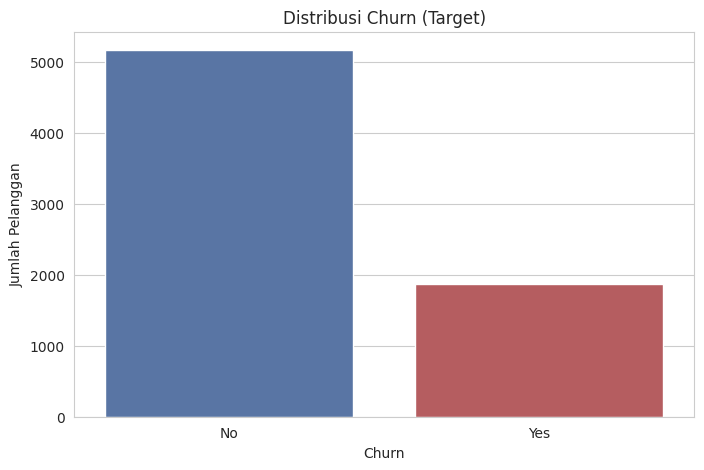

In [52]:
# Distribusi target
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure()
sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#C44E52"])
plt.title("Distribusi Churn (Target)")
plt.ylabel("Jumlah Pelanggan")
plt.show()


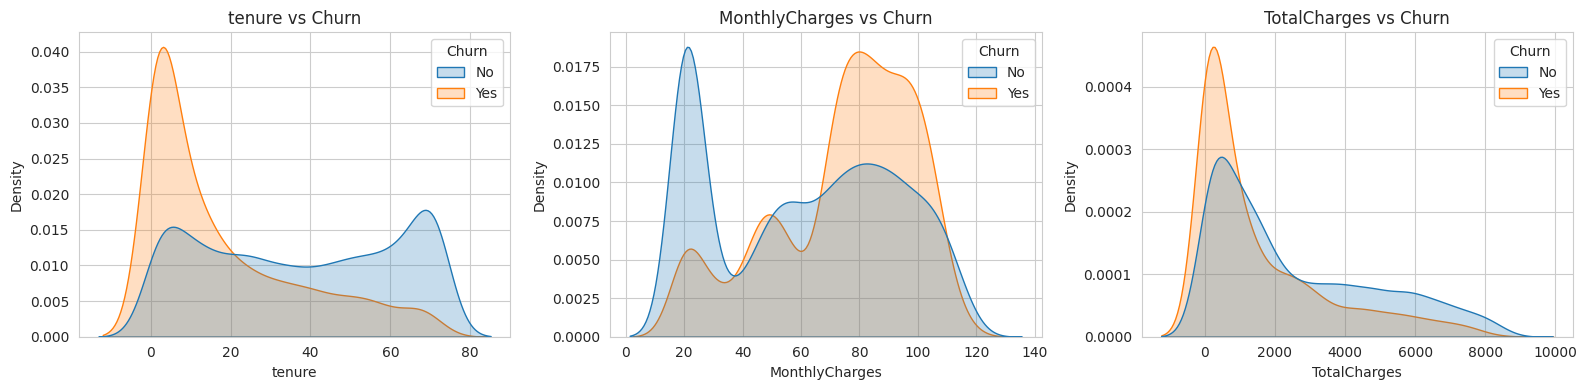

In [53]:
# Distribusi fitur numerik terhadap churn
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()


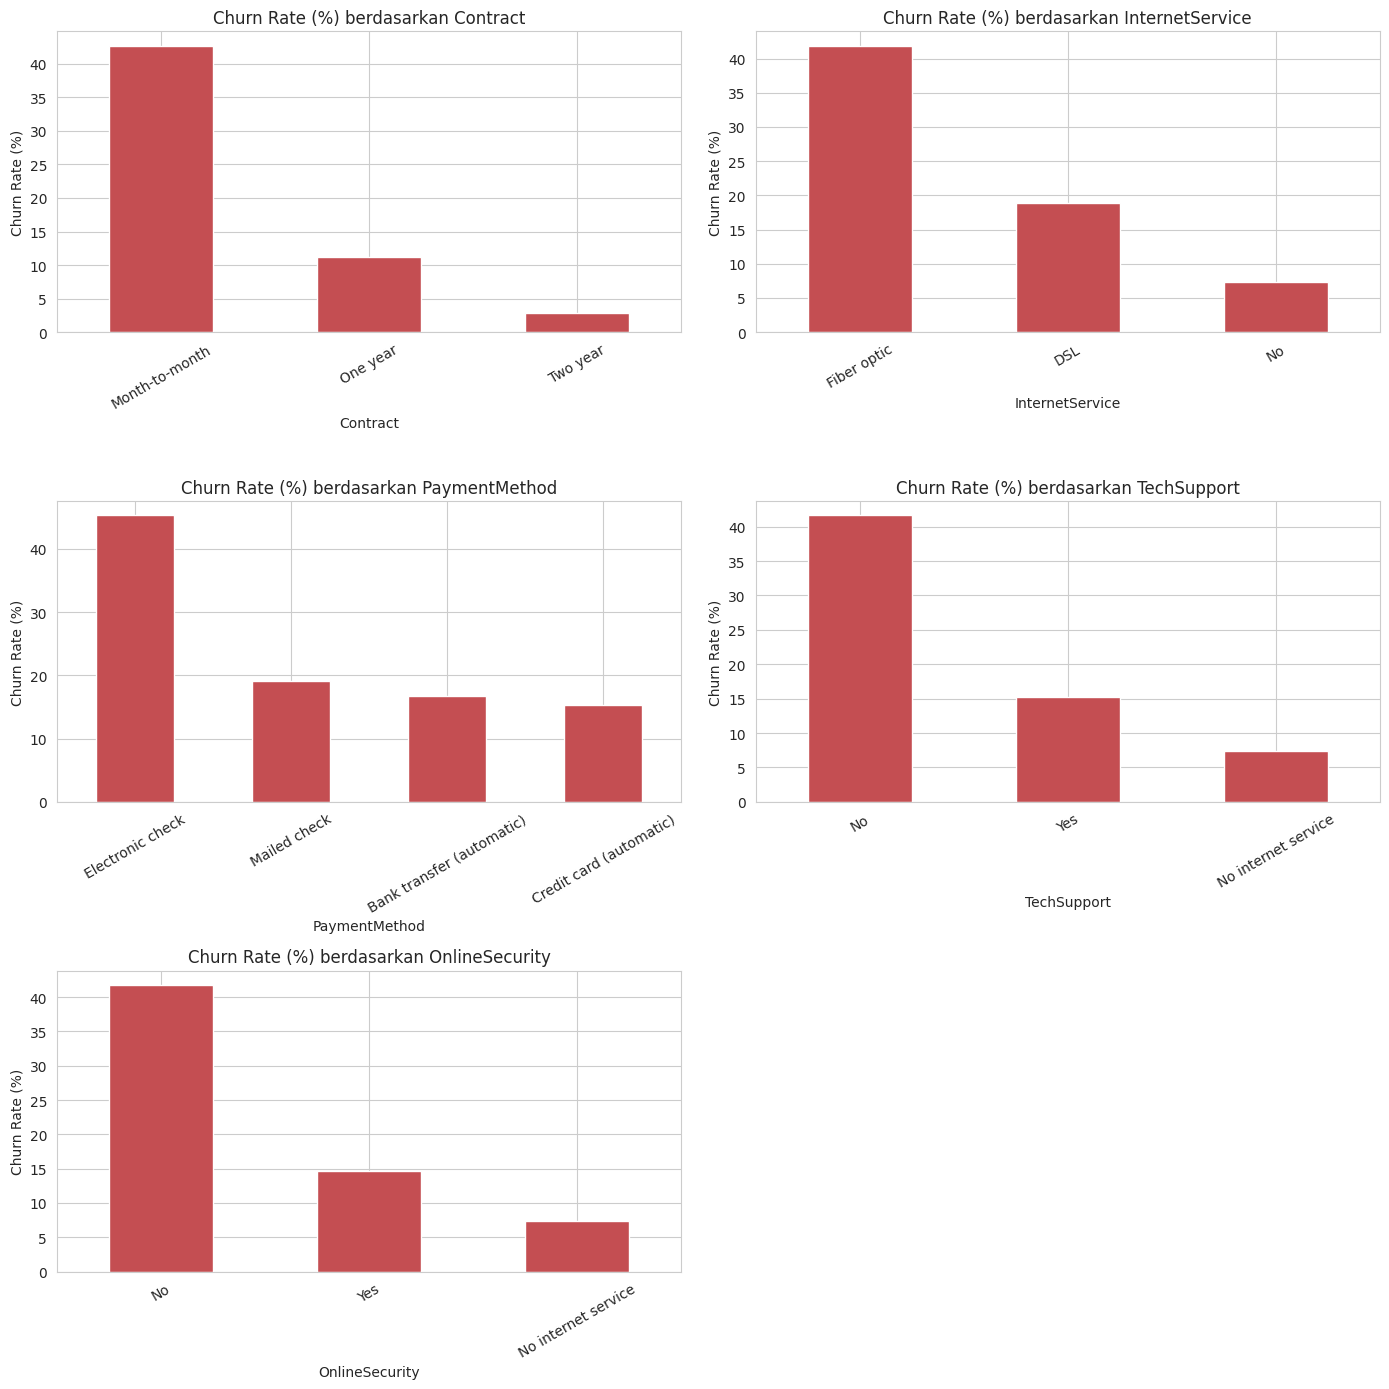

In [54]:
# Churn rate berdasarkan fitur kategorikal kunci
cat_features = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Churn Rate (%) berdasarkan {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis='x', rotation=30)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


**Insight awal dari EDA** (isi ulang sesuai hasil data asli Kaggle setelah dijalankan):
- Pelanggan dengan kontrak **Month-to-month** cenderung memiliki churn rate jauh lebih tinggi dibanding kontrak 1-2 tahun.
- Pelanggan **Fiber optic** menunjukkan churn rate lebih tinggi — kemungkinan terkait harga atau kualitas layanan.
- Pelanggan tanpa **Tech Support** dan **Online Security** lebih rentan churn.
- Tenure rendah (pelanggan baru) berkorelasi dengan churn yang lebih tinggi.


## 2. Data Cleaning & Feature Engineering

In [55]:
df_model = df.copy()

# Drop ID (tidak informatif untuk model)
df_model = df_model.drop(columns=["customerID"])

# Isi missing TotalCharges (biasanya customer baru dengan tenure=0)
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median())

# Buat fitur turunan: tenure group
def tenure_group(t):
    if t <= 12:
        return "0-1 tahun"
    elif t <= 24:
        return "1-2 tahun"
    elif t <= 48:
        return "2-4 tahun"
    else:
        return "4+ tahun"

df_model["TenureGroup"] = df_model["tenure"].apply(tenure_group)

# Encode target
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# One-hot encoding untuk kategorikal
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print("Shape setelah encoding:", df_model.shape)
df_model.head()


Shape setelah encoding: (7043, 34)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 tahun,TenureGroup_2-4 tahun,TenureGroup_4+ tahun
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


## 3. Split Data & Handling Imbalanced Data (SMOTE)

In [56]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE:", y_train_res.value_counts().to_dict())


Sebelum SMOTE: {0: 4139, 1: 1495}
Setelah SMOTE: {0: 4139, 1: 4139}


## 4. Modeling

Melatih 3 model klasifikasi untuk dibandingkan:
- **Logistic Regression** — baseline yang interpretable
- **Random Forest** — menangkap interaksi non-linear
- **XGBoost** — biasanya performa terbaik untuk tabular data


In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        eval_metric="logloss", random_state=RANDOM_STATE
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "roc_auc": roc_auc,
        "avg_precision": avg_precision,
    }

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"ROC-AUC: {roc_auc:.3f} | Average Precision: {avg_precision:.3f}")



=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.76      1409

ROC-AUC: 0.813 | Average Precision: 0.604

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1035
       Churn       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC: 0.837 | Average Precision: 0.625

=== XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.55      0.63      0.59       374

    accuracy                 

## 5. Evaluasi & Perbandingan Model

                      ROC-AUC  Average Precision
Random Forest        0.836802           0.625170
XGBoost              0.825873           0.623772
Logistic Regression  0.813002           0.604462


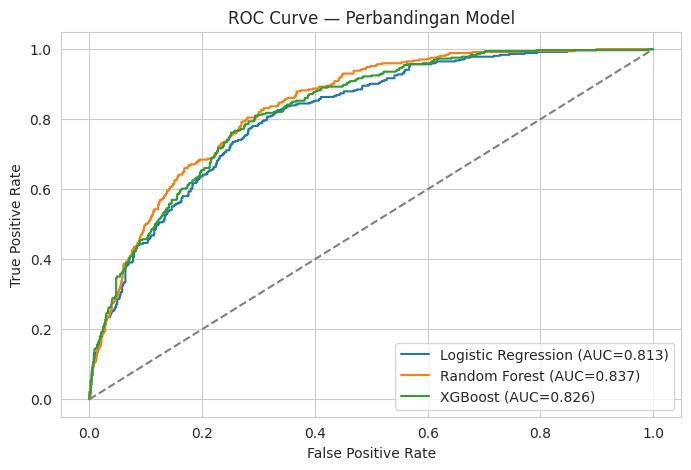

In [58]:
comparison = pd.DataFrame({
    name: {"ROC-AUC": res["roc_auc"], "Average Precision": res["avg_precision"]}
    for name, res in results.items()
}).T.sort_values("ROC-AUC", ascending=False)

print(comparison)

# ROC Curve semua model
plt.figure()
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Perbandingan Model")
plt.legend()
plt.show()


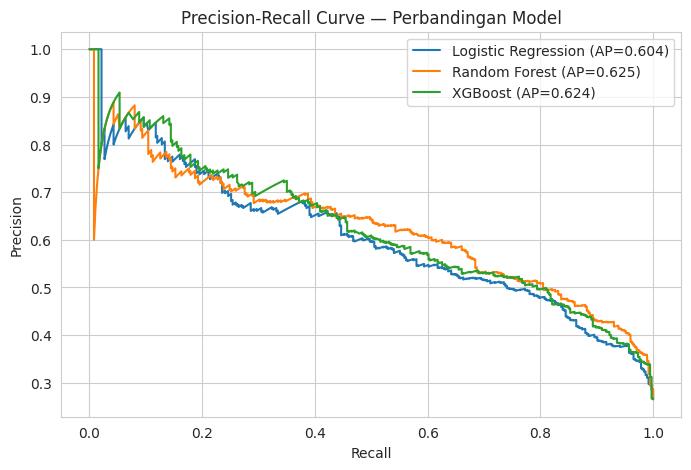

In [59]:
# Precision-Recall Curve (lebih relevan untuk data imbalanced)
plt.figure()
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res["y_proba"])
    plt.plot(recall, precision, label=f"{name} (AP={res['avg_precision']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Perbandingan Model")
plt.legend()
plt.show()


Model terbaik: Random Forest


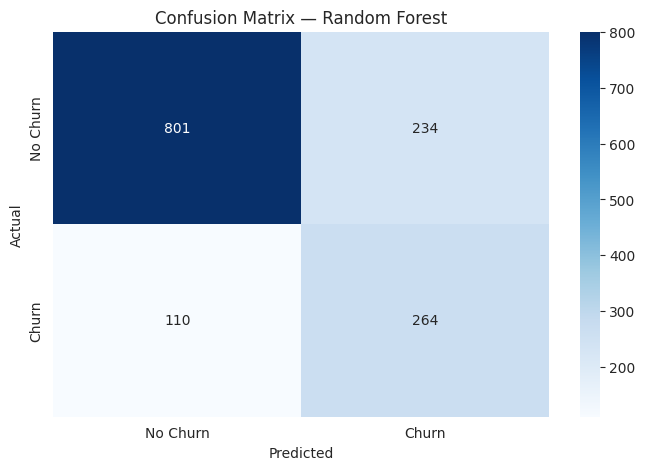

In [60]:
# Pilih model terbaik berdasarkan ROC-AUC
best_model_name = comparison.index[0]
best_model = results[best_model_name]["model"]
print(f"Model terbaik: {best_model_name}")

cm = confusion_matrix(y_test, results[best_model_name]["y_pred"])
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


## 6. Interpretasi Model dengan SHAP

SHAP (SHapley Additive exPlanations) membantu menjelaskan **kontribusi tiap fitur** terhadap prediksi churn — baik secara global (fitur mana yang paling berpengaruh) maupun per individu pelanggan.


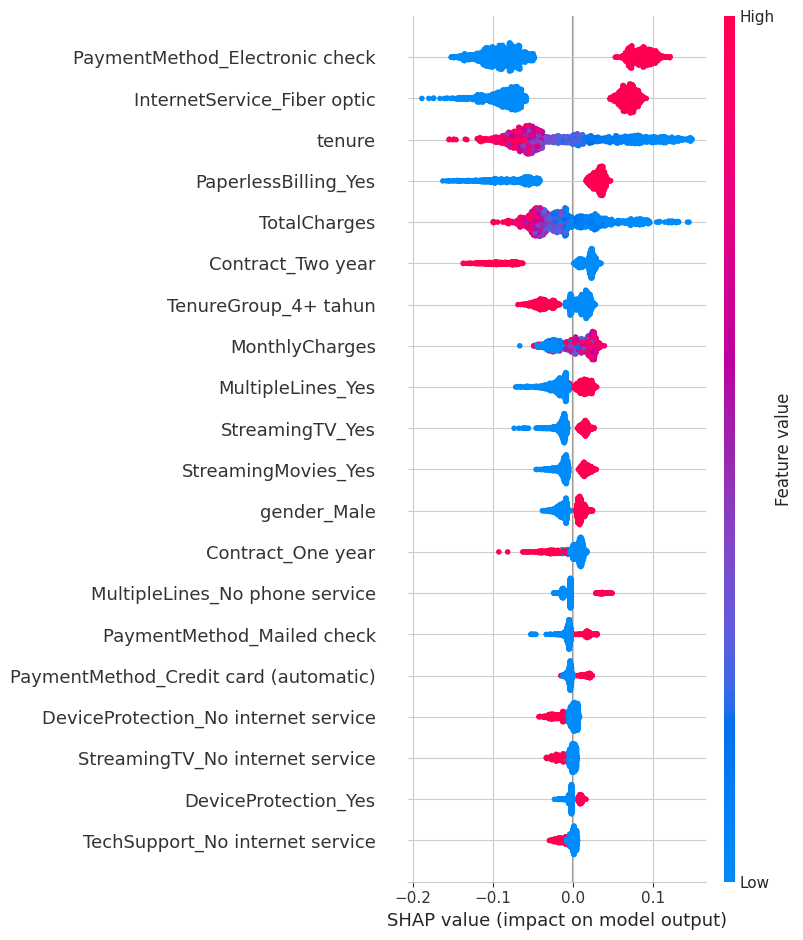

In [61]:
explainer = shap.TreeExplainer(best_model) if best_model_name != "Logistic Regression" else shap.LinearExplainer(best_model, X_train_res)
shap_values = explainer.shap_values(X_test)

# Untuk beberapa model, shap_values bisa berupa list (per kelas) — ambil kelas positif (churn)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test, show=True)


In [62]:
# Feature importance global (rata-rata absolut SHAP value)
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values_plot).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(15))


                           feature  mean_abs_shap
28  PaymentMethod_Electronic check       0.088762
10     InternetService_Fiber optic       0.079496
1                           tenure       0.059757
26            PaperlessBilling_Yes       0.049382
3                     TotalCharges       0.036847
25               Contract_Two year       0.036469
32            TenureGroup_4+ tahun       0.019996
2                   MonthlyCharges       0.018360
9                MultipleLines_Yes       0.017125
21                 StreamingTV_Yes       0.014671
23             StreamingMovies_Yes       0.013878
4                      gender_Male       0.011929
24               Contract_One year       0.011292
8   MultipleLines_No phone service       0.009711
29      PaymentMethod_Mailed check       0.009306


## 7. Business Insight & Rekomendasi

In [63]:
# Analisis segmen: churn rate berdasarkan kombinasi Contract x TenureGroup
segment_analysis = df.copy()
segment_analysis["TotalCharges"] = pd.to_numeric(segment_analysis["TotalCharges"], errors="coerce")
segment_analysis["TenureGroup"] = segment_analysis["tenure"].apply(tenure_group)

segment_churn = (
    segment_analysis.groupby(["Contract", "TenureGroup"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate(%)")
    .sort_values("ChurnRate(%)", ascending=False)
)

print(segment_churn.head(10))


          Contract TenureGroup  ChurnRate(%)
0   Month-to-month   0-1 tahun     51.354062
1   Month-to-month   1-2 tahun     37.720488
2   Month-to-month   2-4 tahun     32.917706
3   Month-to-month    4+ tahun     26.023392
7         One year    4+ tahun     12.933754
6         One year   2-4 tahun     10.617761
4         One year   0-1 tahun     10.483871
5         One year   1-2 tahun      8.121827
11        Two year    4+ tahun      3.325416
10        Two year   2-4 tahun      2.189781


In [64]:
overall_churn_rate = (df["Churn"] == "Yes").mean() * 100
top_segment = segment_churn.iloc[0]
risk_multiplier = top_segment["ChurnRate(%)"] / overall_churn_rate

print(f"Churn rate keseluruhan: {overall_churn_rate:.1f}%")
print(f"Segmen paling berisiko: Contract={top_segment['Contract']}, TenureGroup={top_segment['TenureGroup']}")
print(f"Churn rate segmen ini: {top_segment['ChurnRate(%)']:.1f}% (~{risk_multiplier:.1f}x rata-rata)")


Churn rate keseluruhan: 26.5%
Segmen paling berisiko: Contract=Month-to-month, TenureGroup=0-1 tahun
Churn rate segmen ini: 51.4% (~1.9x rata-rata)


### Ringkasan Rekomendasi Bisnis

Model terbaik yang dipilih adalah **Random Forest** (ROC-AUC 0.837, Average Precision 0.625), 
mengungguli XGBoost (0.826) dan Logistic Regression (0.813). Model ini berhasil mendeteksi 
70.6% pelanggan yang benar-benar akan churn (recall 70.6%, precision 53%).

**Churn rate keseluruhan: 26.5%.**

1. **Segmen paling berisiko: kontrak Month-to-month dengan tenure 0-1 tahun** — churn rate 
   segmen ini **51.4%**, hampir **1.9x lipat** dari rata-rata keseluruhan. Bahkan di dalam 
   kelompok Month-to-month sendiri, terlihat pola menurun jelas seiring tenure bertambah 
   (0-1 tahun: 51.4% → 1-2 tahun: 37.7% → 2-4 tahun: 32.9% → 4+ tahun: 26.0%), menunjukkan 
   periode kritis retensi ada di tahun pertama.
   → **Rekomendasi**: fokuskan program retensi paling agresif pada pelanggan baru (<12 bulan) 
   berkontrak Month-to-month — misalnya diskon migrasi ke kontrak 1 tahun (potongan 1-2 bulan) 
   yang ditawarkan aktif di bulan ke-3 dan ke-6 masa berlangganan.

2. **Efek kontrak jangka panjang sangat signifikan**: churn rate Two year hanya 2.2-3.3% 
   dibanding Month-to-month 26-51% tergantung tenure — perbedaan hingga **15-20x lipat**. 
   Ini juga terkonfirmasi lewat SHAP, di mana `Contract_Two year` justru menurunkan probabilitas 
   churn secara konsisten.
   → **Rekomendasi**: jadikan konversi ke kontrak tahunan sebagai KPI utama tim retensi, bukan 
   sekadar tambahan.

3. **Metode pembayaran Electronic Check adalah fitur SHAP paling berpengaruh secara global**, 
   dengan churn rate ~45% dibanding metode otomatis lain (~15-19%).
   → **Rekomendasi**: kampanye migrasi ke auto-debit/kartu kredit dengan insentif kecil 
   (cashback bulan pertama switch).

4. **Pelanggan Fiber optic tanpa Tech Support** menunjukkan churn rate tertinggi di kategori 
   masing-masing (~42% dan ~41%) — kemungkinan overlap sebagai segmen ganda paling kritis.
   → **Rekomendasi**: bundling gratis Tech Support 3 bulan untuk pelanggan Fiber optic baru.

5. **Untuk deployment**: karena biaya kehilangan pelanggan (customer acquisition cost) 
   biasanya lebih mahal dari biaya retensi, prioritaskan **recall** dibanding precision. 
   Threshold prediksi bisa diturunkan dari default 0.5 agar model menangkap lebih banyak 
   calon churn, meski konsekuensinya lebih banyak false positive yang perlu di-follow up 
   tim retensi (trade-off yang wajar mengingat model saat ini sudah recall 70.6%).